Logistic Regression Model Evaluation: 
 
Accuracy : 0.833
Precision: 0.863
Recall : 0.614
F1 Score : 0.718

Confusion Matrix:
 [[701  38]
 [150 239]]

Classification Report:
               precision    recall  f1-score   support

    Survived       0.82      0.95      0.88       739
        Died       0.86      0.61      0.72       389

    accuracy                           0.83      1128
   macro avg       0.84      0.78      0.80      1128
weighted avg       0.84      0.83      0.83      1128



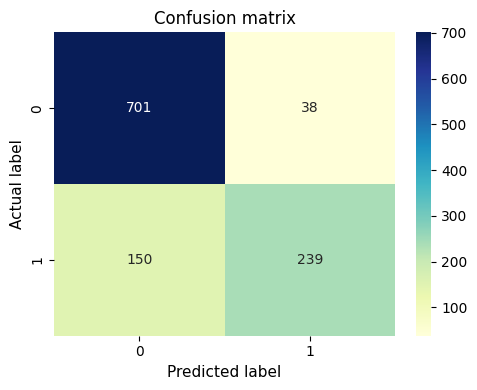

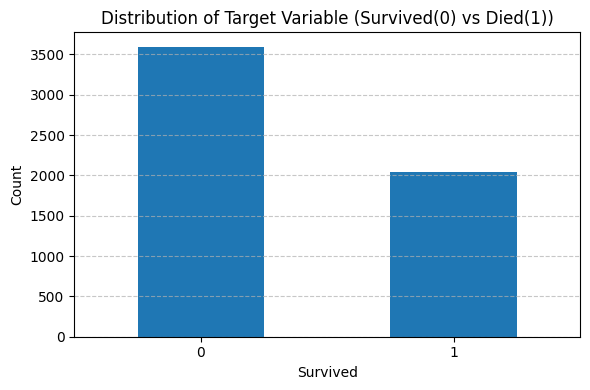

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score,confusion_matrix, classification_report)
# 1️ Load dataset
df = pd.read_csv("framingham_death1.csv")
# Fill missing values with mean
df = df.fillna(df.mean(numeric_only=True))
# Separate features (X) and target (y)
x = df.drop(columns=["Death_Outcome (1 = Died, 0 = Survived)"])
y = df["Death_Outcome (1 = Died, 0 = Survived)"]
# Split into training (80%) and testing (20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
# Train Logistic Regression model
model_regr = LogisticRegression(max_iter=1000, solver='liblinear')
model_regr.fit(x_train_scaled, y_train)
# Make predictions
y_pred = model_regr.predict(x_test_scaled)
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
# Print evaluation report
print("Logistic Regression Model Evaluation: \n ")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred,
target_names=["Survived", "Died"]))
# Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Confusion matrix", fontsize=12)
plt.xlabel("Predicted label", fontsize=11)
plt.ylabel("Actual label", fontsize=11)
plt.tight_layout()
plt.show()
# Visualize target distribution (Survived vs Died)
plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar')
plt.title("Distribution of Target Variable (Survived(0) vs Died(1))", fontsize=12)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()